# **Points projection and transformation**

Visualisation of points projection:
- from cartesian frame to polar frame
- from polar frame to cartesian frame

Visualisation of points transformation with caused by camera movement

!!!! Add here image and schemat !!!

In [34]:
import sys
import os 

import random

import numpy as np
import cv2 

import matplotlib
import matplotlib.pylab as plt

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.utils import project_points, projection_type


### 1. Polar (Spherical) to Cartesian: 

Input is a set of points $(r, \theta, \phi)$, where $r$ is the range, $\theta$ is the azimuth (horizontal angle), and $\phi$ is the elevation (vertical angle).

**Step 1: Project the range onto the $XY$ plane.**

First, we find the horizontal component $r_{xy}$ by projecting $r$ using the elevation angle $\phi$:

$$r_{xy} = r \cdot \cos(\phi)$$

**Step 2: Decompose into $X$ and $Y$ coordinates**

Using the azimuth angle $\theta$, we calculate the forward ($x$) and lateral ($y$) positions:

$$x = r_{xy} \cdot \cos(\theta) = r \cdot \cos(\phi) \cdot \cos(\theta)$$

$$y = r_{xy} \cdot \sin(\theta) = r \cdot \cos(\phi) \cdot \sin(\theta)$$

**Step 3: Calculate the vertical $Z$ coordinate**

The height is determined by the sine of the elevation angle:

$$z = r \cdot \sin(\phi)$$


Note: 
$$
\begin{bmatrix} x \\ y \\ z \end{bmatrix} =
\begin{bmatrix} x_{point} \\ y_{point} \\ z_{point} \end{bmatrix} - 
\begin{bmatrix} x_{vehicle} \\ y_{vehicle} \\ z_{vehicle} \end{bmatrix}
$$

### 2. Cartesian to Polar (Spherical):

In this mode, we convert Cartesian coordinates $(x, y, z)$ back into the spherical parameters $(r, \theta, \phi)$ used by sonar.

**Step 1: Calculate the radial distance $r$**

The range is the Euclidean distance from the origin in 3D space:

$$r = \sqrt{x^2 + y^2 + z^2}$$

**Step 2: Calculate the azimuth angle $\theta$**

The horizontal angle is found using the four-quadrant inverse tangent of the $y$ and $x$ coordinates:

$$\theta = \operatorname{atan2}(y, x)$$

**Step 3: Calculate the elevation angle $\phi$**

The vertical angle is found by taking the inverse tangent of the height $z$ over the horizontal distance $\sqrt{x^2 + y^2}$:

$$\phi = \operatorname{atan2}\left(z, \sqrt{x^2 + y^2}\right)$$

In [35]:
# Prepare test points

min_coord = -10
max_coord = 10
pts_number = 5

test_pts = []

for _ in range(pts_number):
    pt = [random.uniform(min_coord, max_coord) for _ in range(3)]
    test_pts.append(pt)

test_pts = np.array(test_pts, dtype = np.float32)

print(f'Test points: \n{test_pts}')

Test points: 
[[-3.4094791 -5.9520354  5.750822 ]
 [-9.563996   8.318912   4.729514 ]
 [-1.0631669 -5.666942   8.485959 ]
 [-5.5638103  6.314159  -3.9269948]
 [ 1.0347205  4.8451424  7.0727344]]


In [36]:
# projetct and reproject points 
pts_transformed = project_points(test_pts, projection_type.CARTESIAN2POLAR)
pts_transformed_2 = project_points(pts_transformed, projection_type.POLAR2CARTESIAN)

C:\Users\janis\AppData\Local\Temp\ipykernel_3908\2546573236.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter_1 = ax.scatter(test_pts[:,0], test_pts[:,1], test_pts[:,2], c='red', cmap='viridis', s=5)
C:\Users\janis\AppData\Local\Temp\ipykernel_3908\2546573236.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter_2 = ax.scatter(pts_transformed_2[:,0], pts_transformed_2[:,1], pts_transformed_2[:,2], c='green', cmap='viridis', s=30)


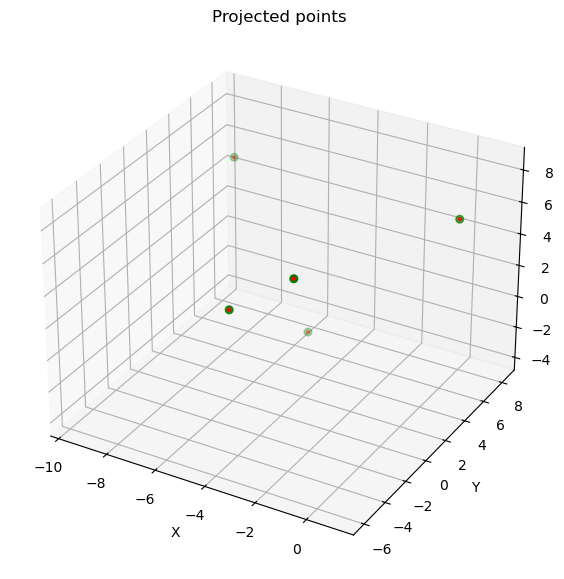

In [37]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter_1 = ax.scatter(test_pts[:,0], test_pts[:,1], test_pts[:,2], c='red', cmap='viridis', s=5)
scatter_2 = ax.scatter(pts_transformed_2[:,0], pts_transformed_2[:,1], pts_transformed_2[:,2], c='green', cmap='viridis', s=30)
# Dodanie opisów
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("Projected points")

# Pasek koloru
# plt.colorbar(scatter_1, label='Orginal')
# plt.colorbar(scatter_2, label='Reprojected')

plt.show()

### **Points tranformation and movement**

1. **Translation Matrix**

Define the translation matrix $T_{t}$ using the coordinates $(x, y, z)$:

$$T_{t}(x, y, z) = \begin{bmatrix} 1 & 0 & 0 & x \\ 0 & 1 & 0 & y \\ 0 & 0 & 1 & z \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

2. **Individual Rotation Matrices**

Define the rotations around the $X$ (Roll), $Y$ (Pitch), and $Z$ (Yaw) axes:

Roll ($\phi$) around X-axis:
$$R_x(\phi) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}$$

Pitch ($\theta$) around Y-axis:
$$R_y(\theta) = \begin{bmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{bmatrix}$$

Yaw ($\psi$) around Z-axis:
$$R_z(\psi) = \begin{bmatrix} \cos\psi & -\sin\psi & 0 \\ \sin\psi & \cos\psi & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

3. **Combined Rotation Matrix ($R$)**

Following the standard ZYX convention (Intrinsic rotations or Extrinsic Yaw-Pitch-Roll), the total rotation matrix $R$ is calculated as:

$$R = R_z(\psi) \cdot R_y(\theta) \cdot R_x(\phi)$$

Multiplying these results in the full $3 \times 3$ rotation matrix:

$$
R = \begin{bmatrix} c\psi c\theta & c\psi s\theta s\phi - s\psi c\phi & c\psi s\theta c\phi + s\psi s\phi \\ s\psi c\theta & s\psi s\theta s\phi + c\psi c\phi & s\psi s\theta c\phi - c\psi s\phi \\ -s\theta & c\theta s\phi & c\theta c\phi \end{bmatrix}
$$

(Note: $c$ stands for $\cos$ and $s$ for $\sin$).

4. **Final Homogeneous Transformation Matrix ($T$)**

Combine the rotation matrix $R$ and the translation vector into a single $4 \times 4$ matrix:

$$T = \begin{bmatrix} R_{11} & R_{12} & R_{13} & x \\ R_{21} & R_{22} & R_{23} & y \\ R_{31} & R_{32} & R_{33} & z \\ 0 & 0 & 0 & 1 \end{bmatrix}$$Substituting the combined rotation values:$$T = \begin{bmatrix} \cos\psi\cos\theta & \cos\psi\sin\theta\sin\phi - \sin\psi\cos\phi & \cos\psi\sin\theta\cos\phi + \sin\psi\sin\phi & x \\ \sin\psi\cos\theta & \sin\psi\sin\theta\sin\phi + \cos\psi\cos\phi & \sin\psi\sin\theta\cos\phi - \cos\psi\sin\phi & y \\ -\sin\theta & \cos\theta\sin\phi & \cos\theta\cos\phi & z \\ 0 & 0 & 0 & 1 \end{bmatrix}$$



5. **New point after tranformation.**

$$
 \begin{bmatrix} x' \\ y' \\ z' \\ 1\end{bmatrix} 
= T\begin{bmatrix} x \\ y \\ z \\ 1\end{bmatrix} 

$$

In [38]:
from src.models.utils import affine_matrix



pt = [random.uniform(min_coord, max_coord) for _ in range(3)]
pt.append(1) # uniform coords: 1 if can be shifted (eg. point), 0 if can be only rotated (eg. velocity)
pt = np.array(pt, dtype=np.float32)
pt = pt[:, np.newaxis]

shift = [random.uniform(min_coord, max_coord) for _ in range(3)] 
rotation = [random.uniform(-np.pi, np.pi) for _ in range(3)]

movement = np.concatenate((shift, rotation), axis = 0)

T = affine_matrix(movement)

pt_2 = T @ pt

print(f'Point 1: \n{pt}\n\nPoint 2: \n{pt_2}\n\nAffine matrix: \n{T}')




Point 1: 
[[ 1.089745 ]
 [-9.60434  ]
 [-0.6250613]
 [ 1.       ]]

Point 2: 
[[-5.86781921]
 [12.9224891 ]
 [ 3.05906373]
 [ 1.        ]]

Affine matrix: 
[[ 0.69653018  0.22053466 -0.68279585 -4.93555895]
 [ 0.53006334 -0.79951988  0.28249039  4.84256855]
 [-0.48360993 -0.55868813 -0.67378707 -2.20091344]
 [ 0.          0.          0.          1.        ]]


C:\Users\janis\AppData\Local\Temp\ipykernel_3908\1358477995.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter((0, pt[0,0], pt_2[0,0]), (0, pt[1,0], pt_2[1,0]), (0, pt[2,0], pt_2[2,0]), c='blue', cmap='viridis', s=30)


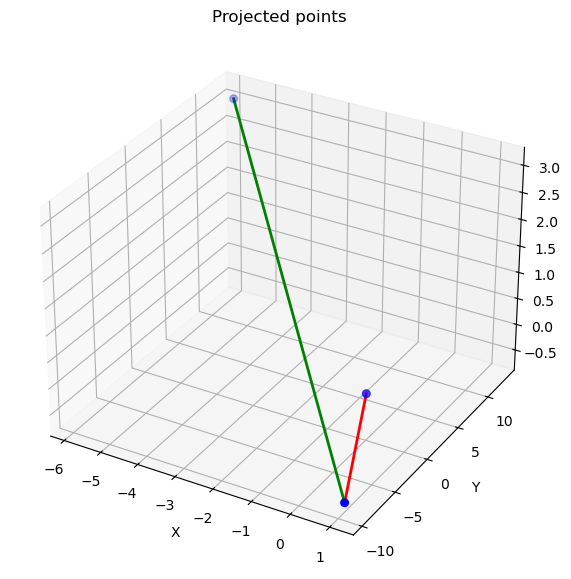

+---------------------------+
  Movement:
  x: -4.935558953179456
  y: 4.84256854957874
  z: -2.2009134391753165
  roll: 39.66471074459261
  pitch: 151.07856098895397
  yaw: -142.72866361529722
+---------------------------+


In [42]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')



ax.plot([0, pt[0,0]], [0, pt[1,0]], [0, pt[2,0]], color='red', label='Original point', linewidth=2)
ax.plot([pt[0,0], pt_2[0,0]], [pt[1,0], pt_2[1,0]], [pt[2,0], pt_2[2,0]], color='green', label='Moved point', linewidth=2)

scatter = ax.scatter((0, pt[0,0], pt_2[0,0]), (0, pt[1,0], pt_2[1,0]), (0, pt[2,0], pt_2[2,0]), c='blue', cmap='viridis', s=30)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("Projected points")

plt.show()


print(f'+---------------------------+\n  Movement:\n  x: {movement[0]}\n  y: {movement[1]}\n  z: {movement[2]}\n  roll: {movement[3]*180/np.pi}\n  pitch: {movement[4]*180/np.pi}\n  yaw: {movement[5]*180/np.pi}\n+---------------------------+')